# Maintenance prédictive — première optimisation Grid Search

## Objectif concret

Ce notebook reprend la préparation du notebook `02-maintenance-random-forest.ipynb` et réalise une première recherche d'hyperparamètres avec `GridSearchCV`. L'objectif est d'obtenir une configuration de `RandomForestClassifier` mieux étayée que le réglage manuel, sans dépasser 30 minutes d'exécution.

Le test reste hors de la recherche. `GridSearchCV` travaille uniquement sur le train avec trois folds chronologiques. La validation déjà réservée sert ensuite à choisir le seuil F2, puis le test sert à mesurer une fois le modèle et le seuil figés.

## Prérequis et point de départ observable

- ouvrir ce notebook depuis la racine du projet `indusense` ;
- sélectionner l'interpréteur `C:\Users\SimonFUGER\.virtualenvs\indusense\Scripts\python.exe` ;
- disposer de `datas/gold_dataset_20260622-080603.csv` ;
- exécuter les cellules dans l'ordre et vérifier les marqueurs affichés.

Le budget initial comporte **8 configurations × 3 folds = 24 fits**. Un fit de contrôle avec 50 arbres estime le temps nécessaire. Si l'estimation prudente dépasse 20 minutes, la grille est réduite à 4 configurations ; si elle reste trop coûteuse, la cellule s'arrête avant de lancer la recherche. Cette marge réserve du temps pour le refit final et l'évaluation.


In [1]:
from pathlib import Path

import pandas as pd
from tabulate import tabulate

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / 'datas' / 'gold_dataset_20260622-080603.csv'

assert (PROJECT_ROOT / 'pyproject.toml').exists(), (
    'Ouvrir le notebook depuis la racine du projet indusense.'
)
assert DATA_PATH.exists(), f'Fichier Gold introuvable : {DATA_PATH}'

# Les dates sont converties dès la lecture afin de permettre les contrôles chronologiques.
gold = pd.read_csv(
    DATA_PATH,
    parse_dates=['window_start', 'window_end'],
)
PREDICTION_TIME_COLUMN = 'window_end'
gold = gold.sort_values(
    ['machine_id_std', PREDICTION_TIME_COLUMN],
    kind='stable',
).reset_index(drop=True)

# Une ligne doit représenter un seul instant de prédiction pour une seule machine.
grain_columns = ['machine_id_std', PREDICTION_TIME_COLUMN]
duplicate_grain_count = int(gold.duplicated(grain_columns).sum())
assert duplicate_grain_count == 0, (
    f'{duplicate_grain_count} doublons détectés sur le grain {grain_columns}.'
)

window_durations = gold['window_end'] - gold['window_start']
assert window_durations.eq(pd.Timedelta(hours=1)).all(), (
    'Chaque fenêtre Gold doit couvrir exactement une heure.'
)

dataset_summary = [
    ['Fichier chargé', DATA_PATH.name],
    ['Nombre de lignes', f'{len(gold):,}'.replace(',', ' ')],
    ['Nombre de colonnes', gold.shape[1]],
    ['Nombre de machines', gold['machine_id_std'].nunique()],
    ['Première ancre', gold[PREDICTION_TIME_COLUMN].min()],
    ['Dernière ancre', gold[PREDICTION_TIME_COLUMN].max()],
    ['Durée de chaque fenêtre', '1 heure'],
    ['Doublons machine + ancre', duplicate_grain_count],
]

print(tabulate(dataset_summary, headers=['Contrôle', 'Résultat'], tablefmt='github'))

| Contrôle                 | Résultat                         |
|--------------------------|----------------------------------|
| Fichier chargé           | gold_dataset_20260622-080603.csv |
| Nombre de lignes         | 134 280                          |
| Nombre de colonnes       | 100                              |
| Nombre de machines       | 15                               |
| Première ancre           | 2025-06-01 01:00:00              |
| Dernière ancre           | 2026-06-09 00:00:00              |
| Durée de chaque fenêtre  | 1 heure                          |
| Doublons machine + ancre | 0                                |


## Lecture du résultat précédent : quel dataset avons-nous ?

Le Gold dataset contient **134 280 observations**, **100 colonnes** et **15 machines** entre le 1er juin 2025 et le 9 juin 2026. Une observation correspond à une machine et à une ancre horaire ; ce n'est donc pas une panne individuelle, mais un état calculé à partir d'une fenêtre d'une heure. Les `0` doublons confirment que chaque couple `(machine, ancre)` apparaît une seule fois : le **grain** annoncé est respecté. Le grain est l'unité exacte représentée par une ligne.

Ce contrôle ne dit encore rien sur la capacité à prédire. Il établit seulement que les données ont la structure attendue. Les fenêtres successives d'une même machine restent proches dans le temps et peuvent partager de l'information : les 134 280 lignes ne doivent donc pas être interprétées comme autant d'événements totalement indépendants.

## Choisir la cible et vérifier le découpage temporel

L'**horizon de prédiction** est la durée future couverte par la question métier. Nous retenons `label_failure_next_24h` : `1` signifie qu'une panne est observée dans les 24 heures suivantes, `0` signifie qu'aucune panne n'y est observée.

Le fichier fournit trois jeux dans `split_set`. Le jeu d'**entraînement** ajuste le futur modèle ; la **validation** sert à comparer des choix et à fixer le seuil ; le **test** reste à l'écart jusqu'à l'évaluation finale. La cellule suivante vérifie que ces périodes ne se chevauchent pas et mesure le taux de positifs dans chacune.

### Pourquoi cet ordre est indispensable

Le découpage est **chronologique** : le train est le passé connu, la validation une période plus récente sur laquelle on prend les décisions de modélisation, puis le test représente une période future non consultée. Un découpage aléatoire mélangerait potentiellement des observations voisines dans le passé et le futur ; il donnerait une estimation trop optimiste de la généralisation. La validation n'est donc pas un second entraînement, et le test n'est pas un espace d'essais supplémentaire.

**À vérifier après la cellule 3.** Le tableau doit présenter les trois jeux dans l'ordre `train`, `validation`, `test`, avec une dernière ancre du train strictement antérieure à la première ancre de validation, puis le même ordre entre validation et test. Le taux de panne est la **prévalence** de la classe positive ; il servira de repère pour interpréter la PR-AUC.

In [2]:
TARGET_COLUMN = 'label_failure_next_24h'
SPLIT_COLUMN = 'split_set'
EXPECTED_SPLITS = ['train', 'validation', 'test']

required_columns = {
    'machine_id_std', 'window_start', PREDICTION_TIME_COLUMN, TARGET_COLUMN, SPLIT_COLUMN
}
missing_required_columns = sorted(required_columns.difference(gold.columns))
assert not missing_required_columns, (
    f'Colonnes obligatoires absentes : {missing_required_columns}'
)

observed_splits = gold[SPLIT_COLUMN].dropna().unique().tolist()
assert observed_splits == EXPECTED_SPLITS, (
    f'Ordre des splits inattendu : {observed_splits}'
)
assert set(gold[TARGET_COLUMN].dropna().unique()).issubset({False, True, 0, 1}), (
    f'La cible {TARGET_COLUMN} doit être binaire.'
)
assert not gold[TARGET_COLUMN].isna().any(), 'La cible contient des valeurs manquantes.'

split_rows = []
for split_name in EXPECTED_SPLITS:
    split_data = gold.loc[gold[SPLIT_COLUMN].eq(split_name)]
    split_rows.append([
        split_name,
        len(split_data),
        split_data[PREDICTION_TIME_COLUMN].min(),
        split_data[PREDICTION_TIME_COLUMN].max(),
        int(split_data[TARGET_COLUMN].sum()),
        f"{split_data[TARGET_COLUMN].mean():.2%}",
    ])

split_periods = {row[0]: (row[2], row[3]) for row in split_rows}
assert split_periods['train'][1] < split_periods['validation'][0]
assert split_periods['validation'][1] < split_periods['test'][0]

print(tabulate(
    split_rows,
    headers=['Jeu', 'Lignes', 'Première ancre', 'Dernière ancre', 'Positifs', 'Taux positif'],
    tablefmt='github',
))

| Jeu        |   Lignes | Première ancre      | Dernière ancre      |   Positifs | Taux positif   |
|------------|----------|---------------------|---------------------|------------|----------------|
| train      |    93990 | 2025-06-01 01:00:00 | 2026-02-17 02:00:00 |      15598 | 16.60%         |
| validation |    20145 | 2026-02-17 03:00:00 | 2026-04-14 01:00:00 |       3472 | 17.24%         |
| test       |    20145 | 2026-04-14 02:00:00 | 2026-06-09 00:00:00 |       3478 | 17.26%         |


## Lecture du résultat précédent : les périodes sont-elles bien séparées ?

Le train contient **93 990 lignes**, puis la validation et le test **20 145 lignes chacun**. Les bornes s'enchaînent sans chevauchement : le train s'arrête le 17 février 2026 à 02 h, la validation commence à 03 h ; elle s'arrête le 14 avril à 01 h et le test commence à 02 h. Cela confirme un protocole passé → futur cohérent avec l'usage réel.

La prévalence passe de **16,60 %** sur le train à **17,24 %** sur la validation et **17,26 %** sur le test. Ces taux proches indiquent que la fréquence globale des pannes reste relativement stable entre les trois périodes. Cela ne prouve toutefois pas que les relations entre capteurs et pannes sont identiques : un changement de comportement des variables peut exister même avec une prévalence stable.

**Conclusion de l'étape :** les rôles sont séparés correctement. Le train servira au `fit`, la validation aux choix, et le test à la mesure finale. Voir [la section sur les trois jeux](../../../../docs/02-sprint-2/04-revisions/06-evaluation-des-modeles.md#2-séparer-entraînement-validation-et-test).

## Séparer les features et la cible sans fuite

Les colonnes `future_incident_count_*` décrivent directement le futur : elles doivent être exclues. Les autres `label_failure_next_*` sont également des cibles futures et ne peuvent pas devenir des features.

L'identifiant de machine, les deux timestamps bruts et `split_set` sont conservés pour la traçabilité et les contrôles, mais pas fournis à cette première baseline. Une **baseline** est un premier modèle simple qui sert de référence.

La cellule suivante construit la liste des features autorisées, crée les matrices `X` et les cibles `y` pour chaque période, puis vérifie leurs dimensions. Elle ne réalise encore ni imputation, ni standardisation, ni entraînement.

### Règle de disponibilité à l'instant de prédiction

Pour décider à `window_end`, chaque variable explicative doit être connue au plus tard à `window_end`. Une colonne `future_incident_count_*` ou un autre `label_failure_next_*` décrit une conséquence future : l'utiliser rendrait la prédiction artificiellement facile et créerait une **fuite de données**. Les identifiants, les dates brutes et `split_set` sont retirés de cette baseline afin que le modèle n'apprenne pas un raccourci lié à la machine ou à la période plutôt qu'un signal de maintenance.

`X_train`, `X_validation` et `X_test` sont les **matrices de variables explicatives** ; `y_train`, `y_validation` et `y_test` sont les **vecteurs de cible** correspondants. **À vérifier après la cellule 5 :** les trois assertions confirment l'absence de labels futurs et de comptes futurs dans les features, et les tableaux doivent montrer le même nombre de colonnes pour les trois jeux.

In [3]:
label_columns = [column for column in gold.columns if column.startswith('label_failure_next_')]
future_information_columns = [
    column for column in gold.columns if column.startswith('future_incident_count_')
]
identifier_columns = ['machine_id_std']
raw_time_columns = ['window_start', 'window_end']
control_columns = [SPLIT_COLUMN]

excluded_columns = list(dict.fromkeys(
    identifier_columns
    + raw_time_columns
    + control_columns
    + label_columns
    + future_information_columns
))
feature_columns = [column for column in gold.columns if column not in excluded_columns]

# Cette baseline accepte uniquement des variables numériques ou booléennes.
non_numeric_features = gold[feature_columns].select_dtypes(
    exclude=['number', 'bool'],
).columns.tolist()
assert TARGET_COLUMN not in feature_columns
assert not set(future_information_columns).intersection(feature_columns)
assert not set(label_columns).intersection(feature_columns)
assert not non_numeric_features, f'Features non numériques : {non_numeric_features}'

def extract_split(split_name):
    mask = gold[SPLIT_COLUMN].eq(split_name)
    X = gold.loc[mask, feature_columns].copy()
    y = gold.loc[mask, TARGET_COLUMN].astype('int8').copy()
    assert len(X) == len(y)
    assert X.index.equals(y.index)
    return X, y

X_train, y_train = extract_split('train')
X_validation, y_validation = extract_split('validation')
X_test, y_test = extract_split('test')

exclusion_summary = [
    ['Identifiants', len(identifier_columns), ', '.join(identifier_columns)],
    ['Temps bruts', len(raw_time_columns), ', '.join(raw_time_columns)],
    ['Contrôle du split', len(control_columns), ', '.join(control_columns)],
    ['Labels futurs', len(label_columns), ', '.join(label_columns)],
    ['Comptages futurs', len(future_information_columns), ', '.join(future_information_columns)],
]
split_shape_summary = [
    ['train', X_train.shape[0], X_train.shape[1], int(y_train.sum()), int(X_train.isna().sum().sum())],
    ['validation', X_validation.shape[0], X_validation.shape[1], int(y_validation.sum()), int(X_validation.isna().sum().sum())],
    ['test', X_test.shape[0], X_test.shape[1], int(y_test.sum()), int(X_test.isna().sum().sum())],
]

print('Politique d’exclusion :')
print(tabulate(
    exclusion_summary,
    headers=['Famille', 'Nombre', 'Colonnes'],
    tablefmt='github',
))
print(f'\nFeatures retenues : {len(feature_columns)}')
print(f'Premières features : {feature_columns[:8]}')
print('\nJeux prêts pour la prochaine partie :')
print(tabulate(
    split_shape_summary,
    headers=['Jeu', 'Lignes X', 'Colonnes X', 'Positifs y', 'NaN dans X'],
    tablefmt='github',
))
print('\nPARTIE_1_VALIDEE : données séparées sans imputation, standardisation ni modèle.')

Politique d’exclusion :
| Famille           |   Nombre | Colonnes                                                                                                  |
|-------------------|----------|-----------------------------------------------------------------------------------------------------------|
| Identifiants      |        1 | machine_id_std                                                                                            |
| Temps bruts       |        2 | window_start, window_end                                                                                  |
| Contrôle du split |        1 | split_set                                                                                                 |
| Labels futurs     |        4 | label_failure_next_6h, label_failure_next_12h, label_failure_next_24h, label_failure_next_48h             |
| Comptages futurs  |        4 | future_incident_count_6h, future_incident_count_12h, future_incident_count_24h, future_incident_c

## Lecture du résultat précédent : que donnera-t-on réellement au modèle ?

Sur les **100 colonnes** initiales, 12 sont exclues du modèle : 1 identifiant, 2 timestamps, 1 colonne de contrôle, 4 labels futurs et 4 comptages futurs. Il reste **88 variables explicatives**. Cette exclusion est une décision de protocole, pas un nettoyage arbitraire : elle empêche le modèle d'utiliser la réponse attendue ou une information postérieure à `window_end`.

Les matrices contiennent encore des valeurs manquantes : **185 053** dans le train, **37 875** dans la validation et **37 739** dans le test. Rapporté au nombre total de cases, cela représente environ **2,24 %**, **2,14 %** et **2,13 %**. Aucune ligne n'est supprimée ici ; l'imputation sera apprise plus tard dans le Pipeline, uniquement sur le train.

Le marqueur `PARTIE_1_VALIDEE` signifie que la séparation `X/y` est techniquement cohérente. Il ne signifie pas encore qu'un modèle a été entraîné ni qu'il est performant. Voir [la démarche Indusense sans fuite](../../../../docs/02-sprint-2/04-revisions/05-classification-binaire-et-decoupage-temporel.md#démarche-pour-indusense).

## Mesurer et traiter le déséquilibre des classes

Une classe est **minoritaire** lorsqu'elle contient nettement moins d'exemples que l'autre. Ici, les pannes sont moins fréquentes que les non-pannes. Une prédiction toujours égale à `0` obtiendrait donc une accuracy élevée sans détecter la moindre panne. L'**accuracy** est la proportion totale de prédictions correctes ; elle ne sera pas notre métrique principale.

La régression logistique utilisera `class_weight='balanced'`. Scikit-learn donnera automatiquement plus de poids aux erreurs commises sur la classe minoritaire, avec des poids calculés uniquement à partir du jeu d'entraînement. `scale_pos_weight` répond au même besoin pour XGBoost, mais aucun modèle XGBoost n'est entraîné dans ce TP.

La cellule suivante calcule la répartition des classes dans chaque période, les poids théoriques du train et l'accuracy trompeuse d'une règle qui prédirait toujours l'absence de panne.

### Lire le déséquilibre avec les mots du cours

La classe `1` est la **classe positive** : une panne dans l'horizon de 24 heures. La classe `0` est la **classe négative** : pas de panne dans cet horizon. L'accuracy vaut `(TP + TN) / (TP + TN + FP + FN)` ; elle peut être élevée simplement parce que les non-pannes sont nombreuses. Une règle « toujours 0 » a en revanche un **rappel** de 0 : elle ne détecte aucune panne.

`class_weight='balanced'` ne fabrique pas de pannes et ne change pas les données. Pendant l'ajustement, il donne plus de poids à l'erreur sur une panne pour que le modèle ne privilégie pas mécaniquement la classe majoritaire. **À vérifier après la cellule 7 :** la barre des pannes doit être minoritaire dans les trois jeux et l'accuracy de la règle toujours `0` doit être lue comme une référence trompeuse, non comme une performance acceptable.

| Jeu        |   Non-pannes |   Pannes | Taux de panne   | Accuracy toujours 0   |
|------------|--------------|----------|-----------------|-----------------------|
| train      |        78392 |    15598 | 16.60%          | 83.40%                |
| validation |        16673 |     3472 | 17.24%          | 82.76%                |
| test       |        16667 |     3478 | 17.26%          | 82.74%                |

Poids théoriques du train : classe 0 = 0.599, classe 1 = 3.013
Une règle toujours égale à 0 atteindrait 83.40% d'accuracy sur le train, avec 0 % de rappel.


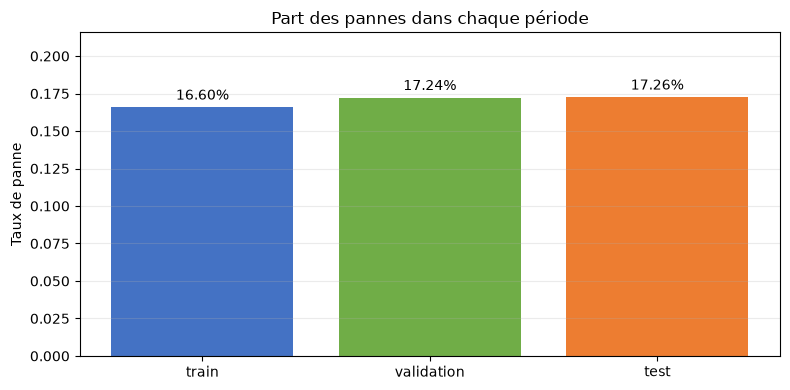

In [4]:
import matplotlib.pyplot as plt
import numpy as np

targets_by_split = {
    'train': y_train,
    'validation': y_validation,
    'test': y_test,
}
class_rows = []
for split_name, target in targets_by_split.items():
    negative_count = int(target.eq(0).sum())
    positive_count = int(target.eq(1).sum())
    class_rows.append([
        split_name,
        negative_count,
        positive_count,
        f'{positive_count / len(target):.2%}',
        f'{negative_count / len(target):.2%}',
    ])

train_negative_count = int(y_train.eq(0).sum())
train_positive_count = int(y_train.eq(1).sum())
balanced_weights = {
    0: len(y_train) / (2 * train_negative_count),
    1: len(y_train) / (2 * train_positive_count),
}
majority_accuracy = train_negative_count / len(y_train)

print(tabulate(
    class_rows,
    headers=['Jeu', 'Non-pannes', 'Pannes', 'Taux de panne', 'Accuracy toujours 0'],
    tablefmt='github',
))
print(f"\nPoids théoriques du train : classe 0 = {balanced_weights[0]:.3f}, classe 1 = {balanced_weights[1]:.3f}")
print(f"Une règle toujours égale à 0 atteindrait {majority_accuracy:.2%} d'accuracy sur le train, avec 0 % de rappel.")

positive_rates = [target.mean() for target in targets_by_split.values()]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(targets_by_split.keys(), positive_rates, color=['#4472C4', '#70AD47', '#ED7D31'])
ax.bar_label(bars, labels=[f'{rate:.2%}' for rate in positive_rates], padding=3)
ax.set_title('Part des pannes dans chaque période')
ax.set_ylabel('Taux de panne')
ax.set_ylim(0, max(positive_rates) * 1.25)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## Lecture du résultat précédent : pourquoi l'accuracy nous tromperait-elle ?

Dans le train, on observe **15 598 pannes** contre **78 392 non-pannes**. Une règle qui répond toujours « pas de panne » aurait donc **83,40 % d'accuracy**, alors qu'elle manquerait les 15 598 pannes : son rappel serait de **0 %**. Ce résultat illustre pourquoi une valeur élevée n'est utile que si la métrique correspond au besoin métier.

Le poids théorique de la classe positive vaut **3,013**, contre **0,599** pour la classe négative. Une erreur sur une panne pèsera donc environ cinq fois plus qu'une erreur sur une non-panne pendant l'entraînement. Cela pousse le modèle à prêter attention aux pannes rares, mais ne garantit ni un bon rappel ni une bonne précision : ces qualités devront être mesurées.

**Conclusion de l'étape :** l'accuracy restera une information secondaire. Pour ce cas, nous suivrons surtout la courbe précision-rappel, puis le rappel, la précision, F2 et les nombres de faux positifs/faux négatifs. Voir [les métriques de classification](../../../../docs/02-sprint-2/04-revisions/06-evaluation-des-modeles.md#5-classification-prédire-une-classe).

## Construire et entraîner la baseline

Une **baseline** est un premier modèle simple servant de référence pour juger les modèles futurs. Nous utilisons une **régression logistique** : malgré son nom, c'est un algorithme de classification. Il combine linéairement les variables, puis applique une fonction logistique qui ramène le résultat entre 0 et 1. Dans ce notebook pondéré, cette sortie est traitée comme un score de risque à ordonner et à seuiller ; sa calibration en probabilité réelle n'est pas démontrée.

Un **Pipeline** scikit-learn enchaîne les transformations dans un ordre fixe :

1. `SimpleImputer(strategy='median')` remplace chaque valeur manquante par la médiane de sa colonne ;
2. `StandardScaler()` centre et réduit les variables afin qu'elles soient sur des échelles comparables ;
3. `LogisticRegression(class_weight='balanced')` apprend la relation entre les features et la cible en compensant le déséquilibre.

L'appel à `fit` ne reçoit que le train. Les médianes, moyennes, écarts-types et coefficients sont donc appris sans regarder la validation ni le test. La cellule suivante entraîne ce pipeline et produit des scores pour le train et la validation.

### Ce que le Pipeline apprend, dans quel ordre

L'**imputation** complète une valeur manquante avec la médiane calculée sur le train : elle rend les données exploitables sans consulter le futur. La **standardisation** retire la moyenne et divise par l'écart-type appris sur le train ; les variables sont ainsi comparables pour l'optimisation de la régression logistique. Enfin, la régression logistique apprend des **coefficients** qui combinent les variables explicatives pour ordonner les observations selon leur risque de panne.

Le Pipeline garantit que, lors de `predict_proba(X_validation)`, les mêmes transformations déjà apprises sur le train sont appliquées à la validation, sans nouveau `fit`. **À vérifier après la cellule 9 :** le tableau doit afficher les trois étapes, le nombre de lignes du train, le nombre de variables explicatives et un nombre d'itérations inférieur à `max_iter=2000`. Sinon, la convergence du modèle est à examiner avant de commenter les métriques.

## Étape 1 — Construire une validation croisée chronologique

Un **fold** est une séparation temporaire entre une partie d'entraînement et une partie de validation. Les folds sont construits uniquement dans le jeu `train` existant.

Les 15 machines peuvent partager le même `window_end`. Les frontières sont donc calculées sur les timestamps uniques, puis appliquées à toutes les machines. Ainsi, un instant donné ne peut pas se retrouver à la fois dans le train et la validation d'un fold.

Une zone d'exclusion, appelée **gap**, retire 24 heures entre les deux parties. Elle évite que les labels « panne dans les 24 prochaines heures » placés à la frontière ne regardent la même période que le fold de validation.

**Résultat attendu :** trois lignes doivent apparaître, avec `Fin train < Début validation`, aucun timestamp partagé et les deux classes présentes dans chaque validation.


In [5]:
import numpy as np

N_SPLITS = 3
GAP_HOURS = 24

train_mask = gold[SPLIT_COLUMN].eq('train')
train_timestamps = gold.loc[
    train_mask,
    PREDICTION_TIME_COLUMN,
].reset_index(drop=True)
assert len(train_timestamps) == len(X_train)

unique_train_timestamps = np.sort(train_timestamps.unique())
time_blocks = np.array_split(unique_train_timestamps, N_SPLITS + 1)
temporal_cv = []
fold_rows = []

for fold_id in range(N_SPLITS):
    validation_times = time_blocks[fold_id + 1]
    validation_start = pd.Timestamp(validation_times[0])
    train_cutoff = validation_start - pd.Timedelta(hours=GAP_HOURS)

    fold_train_positions = np.flatnonzero(
        train_timestamps.lt(train_cutoff).to_numpy()
    )
    fold_validation_positions = np.flatnonzero(
        train_timestamps.isin(validation_times).to_numpy()
    )

    fold_train_times = train_timestamps.iloc[fold_train_positions]
    fold_validation_times = train_timestamps.iloc[fold_validation_positions]
    shared_times = set(fold_train_times).intersection(fold_validation_times)

    assert len(fold_train_positions) > 0
    assert len(fold_validation_positions) > 0
    assert fold_train_times.max() < fold_validation_times.min()
    assert not shared_times
    assert y_train.iloc[fold_validation_positions].nunique() == 2

    temporal_cv.append((fold_train_positions, fold_validation_positions))
    fold_rows.append([
        fold_id + 1,
        len(fold_train_positions),
        fold_train_times.min(),
        fold_train_times.max(),
        len(fold_validation_positions),
        fold_validation_times.min(),
        fold_validation_times.max(),
        f'{y_train.iloc[fold_validation_positions].mean():.2%}',
    ])

print(tabulate(
    fold_rows,
    headers=[
        'Fold', 'Lignes train', 'Début train', 'Fin train',
        'Lignes validation', 'Début validation', 'Fin validation',
        'Taux positif validation',
    ],
    tablefmt='github',
))
print(f'\nVALIDATION_CROISEE_VALIDEE : {N_SPLITS} folds temporels, gap={GAP_HOURS} h.')


|   Fold |   Lignes train | Début train         | Fin train           |   Lignes validation | Début validation    | Fin validation      | Taux positif validation   |
|--------|----------------|---------------------|---------------------|---------------------|---------------------|---------------------|---------------------------|
|      1 |          23145 | 2025-06-01 01:00:00 | 2025-08-04 07:00:00 |               23505 | 2025-08-05 08:00:00 | 2025-10-09 14:00:00 | 18.20%                    |
|      2 |          46650 | 2025-06-01 01:00:00 | 2025-10-08 14:00:00 |               23490 | 2025-10-09 15:00:00 | 2025-12-13 20:00:00 | 13.32%                    |
|      3 |          70140 | 2025-06-01 01:00:00 | 2025-12-12 20:00:00 |               23490 | 2025-12-13 21:00:00 | 2026-02-17 02:00:00 | 16.48%                    |

VALIDATION_CROISEE_VALIDEE : 3 folds temporels, gap=24 h.


## Étape 2 — Définir la grille et contrôler le budget

`GridSearchCV` évalue toutes les combinaisons données. Cette première grille fait varier trois hyperparamètres structurants :

- `n_estimators` : nombre d'arbres ;
- `max_depth` : profondeur maximale de chaque arbre ;
- `min_samples_leaf` : nombre minimal d'observations dans une feuille.

`max_features='sqrt'` et `class_weight='balanced_subsample'` restent fixes pour limiter le nombre de combinaisons. La métrique principale est `average_precision`, utilisée ici comme résumé de la courbe précision-rappel. `refit='pr_auc'` réentraîne automatiquement la meilleure configuration sur tout le train après la cross-validation.

Le fit de contrôle est une estimation, pas une garantie mathématique. La recherche est lancée seulement si son coût extrapolé reste inférieur au budget de sécurité de 20 minutes.

**Résultat attendu :** la cellule affiche la grille retenue, l'estimation prudente et le nombre total de fits avant de démarrer `GridSearchCV`.


In [6]:
from time import perf_counter

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
MAX_ESTIMATED_MINUTES = 20
PROBE_TREES = 50
PROBE_MAX_SECONDS = 120

candidate_pipeline = Pipeline([
    ('imputation', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        max_features='sqrt',
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

full_param_grid = {
    'model__n_estimators': [150, 300],
    'model__max_depth': [8, 12],
    'model__min_samples_leaf': [5, 10],
}
reduced_param_grid = {
    'model__n_estimators': [150],
    'model__max_depth': [8, 12],
    'model__min_samples_leaf': [5, 10],
}

probe_train_positions, _ = temporal_cv[0]
probe = clone(candidate_pipeline).set_params(
    model__n_estimators=PROBE_TREES,
    model__max_depth=8,
    model__min_samples_leaf=10,
)
probe_started_at = perf_counter()
probe.fit(
    X_train.iloc[probe_train_positions],
    y_train.iloc[probe_train_positions],
)
probe_seconds = perf_counter() - probe_started_at
assert probe_seconds <= PROBE_MAX_SECONDS, (
    f'Le fit de contrôle a pris {probe_seconds:.1f} s. '
    'Arrêt avant Grid Search pour protéger le plafond de 30 minutes.'
)

def estimate_grid_seconds(param_grid):
    estimated_seconds = 0.0
    reference_rows = len(probe_train_positions)
    for parameters in ParameterGrid(param_grid):
        tree_ratio = parameters['model__n_estimators'] / PROBE_TREES
        for fold_train_positions, _ in temporal_cv:
            row_ratio = len(fold_train_positions) / reference_rows
            estimated_seconds += probe_seconds * tree_ratio * row_ratio
    # Marge pour l'imputation, l'évaluation, les variations de charge et le refit final.
    return estimated_seconds * 1.75 + probe_seconds * 10

param_grid = full_param_grid
estimated_seconds = estimate_grid_seconds(param_grid)
if estimated_seconds > MAX_ESTIMATED_MINUTES * 60:
    param_grid = reduced_param_grid
    estimated_seconds = estimate_grid_seconds(param_grid)

assert estimated_seconds <= MAX_ESTIMATED_MINUTES * 60, (
    f'Estimation {estimated_seconds / 60:.1f} min : recherche non lancée. '
    'Réduire encore la grille ou utiliser une machine plus rapide.'
)

candidate_count = len(ParameterGrid(param_grid))
fit_count = candidate_count * N_SPLITS
print(f'Fit de contrôle : {probe_seconds:.2f} s pour {PROBE_TREES} arbres.')
print(f'Grille retenue : {candidate_count} configurations × {N_SPLITS} folds = {fit_count} fits.')
print(f'Estimation prudente de la recherche : {estimated_seconds / 60:.1f} min.')
print(param_grid)

grid_search = GridSearchCV(
    estimator=candidate_pipeline,
    param_grid=param_grid,
    scoring={
        'pr_auc': 'average_precision',
        'roc_auc': 'roc_auc',
    },
    refit='pr_auc',
    cv=temporal_cv,
    n_jobs=1,
    return_train_score=True,
    verbose=2,
    error_score='raise',
)

search_started_at = perf_counter()
grid_search.fit(X_train, y_train)
grid_search_seconds = perf_counter() - search_started_at
assert grid_search_seconds < 30 * 60, (
    f'La recherche a duré {grid_search_seconds / 60:.1f} min, au-delà du plafond demandé.'
)

candidate_pipeline = grid_search.best_estimator_
print(f'\nDurée réelle Grid Search + refit : {grid_search_seconds / 60:.2f} min.')
print(f'Meilleure PR-AUC CV moyenne : {grid_search.best_score_:.4f}')
print(f'Meilleurs hyperparamètres : {grid_search.best_params_}')
print('\nGRID_SEARCH_VALIDE : meilleure Random Forest réentraînée sur tout le train.')


Fit de contrôle : 0.79 s pour 50 arbres.
Grille retenue : 8 configurations × 3 folds = 24 fits.
Estimation prudente de la recherche : 5.1 min.
{'model__n_estimators': [150, 300], 'model__max_depth': [8, 12], 'model__min_samples_leaf': [5, 10]}
Fitting 3 folds for each of 8 candidates, totalling 24 fits


[CV] END model__max_depth=8, model__min_samples_leaf=5, model__n_estimators=150; total time=   1.7s


[CV] END model__max_depth=8, model__min_samples_leaf=5, model__n_estimators=150; total time=   3.6s


[CV] END model__max_depth=8, model__min_samples_leaf=5, model__n_estimators=150; total time=   5.6s


[CV] END model__max_depth=8, model__min_samples_leaf=5, model__n_estimators=300; total time=   3.3s


...

[CV] END model__max_depth=12, model__min_samples_leaf=10, model__n_estimators=150; total time=   7.4s


[CV] END model__max_depth=12, model__min_samples_leaf=10, model__n_estimators=300; total time=   4.2s


[CV] END model__max_depth=12, model__min_samples_leaf=10, model__n_estimators=300; total time=   9.0s


[CV] END model__max_depth=12, model__min_samples_leaf=10, model__n_estimators=300; total time=  14.4s



Durée réelle Grid Search + refit : 2.67 min.
Meilleure PR-AUC CV moyenne : 0.5620
Meilleurs hyperparamètres : {'model__max_depth': 8, 'model__min_samples_leaf': 10, 'model__n_estimators': 150}

GRID_SEARCH_VALIDE : meilleure Random Forest réentraînée sur tout le train.


## Étape 3 — Analyser toutes les configurations

Le rang seul ne suffit pas. Il faut lire la PR-AUC moyenne, sa dispersion entre les périodes, l'écart avec le train et le temps de fit. Un gain minuscule accompagné d'une forte instabilité ou d'un coût beaucoup plus élevé n'est pas nécessairement utile.

**Résultat attendu :** le tableau contient une ligne par configuration, triée par rang de PR-AUC.


In [7]:
grid_results = pd.DataFrame(grid_search.cv_results_)
result_columns = [
    'rank_test_pr_auc',
    'mean_test_pr_auc',
    'std_test_pr_auc',
    'mean_train_pr_auc',
    'mean_test_roc_auc',
    'mean_fit_time',
    'param_model__n_estimators',
    'param_model__max_depth',
    'param_model__min_samples_leaf',
]
grid_summary = grid_results[result_columns].sort_values('rank_test_pr_auc')
grid_summary['écart_train_validation'] = (
    grid_summary['mean_train_pr_auc'] - grid_summary['mean_test_pr_auc']
)
print(grid_summary.round(4).to_markdown(index=False))

assert len(grid_summary) == len(ParameterGrid(param_grid))
assert grid_summary['mean_test_pr_auc'].notna().all()
print('\nRESULTATS_GRILLE_VALIDES : toutes les configurations ont produit un score.')


|   rank_test_pr_auc |   mean_test_pr_auc |   std_test_pr_auc |   mean_train_pr_auc |   mean_test_roc_auc |   mean_fit_time |   param_model__n_estimators |   param_model__max_depth |   param_model__min_samples_leaf |   écart_train_validation |
|-------------------:|-------------------:|------------------:|--------------------:|--------------------:|----------------:|----------------------------:|-------------------------:|--------------------------------:|-------------------------:|
|                  1 |             0.562  |            0.0603 |              0.7619 |              0.7712 |          3.5866 |                         150 |                        8 |                              10 |                   0.1999 |
|                  2 |             0.5606 |            0.0538 |              0.9019 |              0.7663 |          9.1965 |                         300 |                       12 |                              10 |                   0.3413 |
|                  3 |  

## Étape 4 — Choisir le seuil F2 sur la validation dédiée

La recherche a choisi les hyperparamètres avec la PR-AUC sur les folds internes du train. Le seuil de décision répond à une autre question : à partir de quel score déclencher une alerte ?

Le seuil est choisi sur la validation dédiée pour maximiser le F2. Le F2 donne davantage de poids au rappel, car le TP suppose qu'une panne manquée coûte plus cher qu'une inspection inutile. Le test n'intervient toujours pas.


In [8]:
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

BETA = 2

def choose_f2_threshold(y_true, model_scores):
    curve_precision, curve_recall, thresholds = precision_recall_curve(
        y_true,
        model_scores,
    )
    usable_precision = curve_precision[:-1]
    usable_recall = curve_recall[:-1]
    f2_values = (1 + BETA**2) * usable_precision * usable_recall / (
        BETA**2 * usable_precision + usable_recall + np.finfo(float).eps
    )
    return float(thresholds[int(np.nanargmax(f2_values))])

def metrics_at_threshold(y_true, model_scores, threshold):
    predictions = (model_scores >= threshold).astype('int8')
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1],
    ).ravel()
    return {
        'Seuil F2': threshold,
        'Précision': precision_score(y_true, predictions, zero_division=0),
        'Rappel': recall_score(y_true, predictions, zero_division=0),
        'F1': f1_score(y_true, predictions, zero_division=0),
        'F2': fbeta_score(y_true, predictions, beta=BETA, zero_division=0),
        'VP': int(tp),
        'FP': int(fp),
        'FN': int(fn),
        'VN': int(tn),
    }

validation_scores = candidate_pipeline.predict_proba(X_validation)[:, 1]
selected_threshold = choose_f2_threshold(y_validation, validation_scores)
validation_metrics = {
    'PR-AUC': average_precision_score(y_validation, validation_scores),
    'ROC-AUC': roc_auc_score(y_validation, validation_scores),
    **metrics_at_threshold(y_validation, validation_scores, selected_threshold),
}

print(pd.DataFrame([validation_metrics], index=['Validation']).round(4).to_markdown())
assert 0 < selected_threshold < 1
print('\nSEUIL_VALIDATION_VALIDE : seuil choisi sans consulter le test.')


|            |   PR-AUC |   ROC-AUC |   Seuil F2 |   Précision |   Rappel |     F1 |     F2 |   VP |   FP |   FN |    VN |
|:-----------|---------:|----------:|-----------:|------------:|---------:|-------:|-------:|-----:|-----:|-----:|------:|
| Validation |   0.5869 |    0.7552 |     0.3663 |      0.3597 |   0.6446 | 0.4618 | 0.5565 | 2238 | 3983 | 1234 | 12690 |

SEUIL_VALIDATION_VALIDE : seuil choisi sans consulter le test.


## Étape 5 — Évaluer une fois sur le test

Les hyperparamètres et le seuil sont maintenant figés. Cette cellule mesure la performance finale du candidat optimisé sur le test existant.

Le test ayant déjà été consulté dans le TP précédent, ce résultat reste une comparaison pédagogique. Une validation de production exigerait une période future encore vierge.


In [9]:
test_started_at = perf_counter()
test_scores = candidate_pipeline.predict_proba(X_test)[:, 1]
test_prediction_seconds = perf_counter() - test_started_at
test_metrics = {
    'PR-AUC': average_precision_score(y_test, test_scores),
    'ROC-AUC': roc_auc_score(y_test, test_scores),
    **metrics_at_threshold(y_test, test_scores, selected_threshold),
    'Prédiction test (s)': test_prediction_seconds,
}

comparison = pd.DataFrame(
    [validation_metrics, test_metrics],
    index=['Validation', 'Test'],
)
print(comparison.round(4).to_markdown())

assert test_metrics['PR-AUC'] > y_test.mean()
print(f'\nPrévalence naïve du test : {y_test.mean():.4f}')
print('EVALUATION_TEST_VALIDEE : hyperparamètres et seuil gelés avant le test.')


|            |   PR-AUC |   ROC-AUC |   Seuil F2 |   Précision |   Rappel |     F1 |     F2 |   VP |   FP |   FN |    VN |   Prédiction test (s) |
|:-----------|---------:|----------:|-----------:|------------:|---------:|-------:|-------:|-----:|-----:|-----:|------:|----------------------:|
| Validation |   0.5869 |    0.7552 |     0.3663 |      0.3597 |   0.6446 | 0.4618 | 0.5565 | 2238 | 3983 | 1234 | 12690 |              nan      |
| Test       |   0.6093 |    0.7827 |     0.3663 |      0.3515 |   0.6797 | 0.4633 | 0.5727 | 2364 | 4362 | 1114 | 12305 |                0.0587 |



Prévalence naïve du test : 0.1726
EVALUATION_TEST_VALIDEE : hyperparamètres et seuil gelés avant le test.


## Étape 6 — Conclusion reproductible

La cellule finale récapitule le budget, la configuration retenue et les performances utiles à présenter. Elle ne conclut pas automatiquement que l'optimisation apporte un gain : il faudra comparer le résultat au réglage manuel précédent (`PR-AUC validation = 0,5970`, `PR-AUC test = 0,6156`) en tenant compte de la variabilité entre folds.


In [10]:
manual_validation_pr_auc = 0.5970
manual_test_pr_auc = 0.6156

print('BILAN GRID SEARCH')
print(f'- Configurations évaluées : {candidate_count}')
print(f'- Folds temporels : {N_SPLITS}, avec gap de {GAP_HOURS} h')
print(f'- Durée Grid Search + refit : {grid_search_seconds / 60:.2f} min')
print(f'- Meilleurs hyperparamètres : {grid_search.best_params_}')
print(f'- PR-AUC moyenne en CV interne : {grid_search.best_score_:.4f}')
print(f'- PR-AUC validation dédiée : {validation_metrics["PR-AUC"]:.4f}')
print(f'- Écart validation vs réglage manuel : {validation_metrics["PR-AUC"] - manual_validation_pr_auc:+.4f}')
print(f'- PR-AUC test pédagogique : {test_metrics["PR-AUC"]:.4f}')
print(f'- Écart test vs réglage manuel : {test_metrics["PR-AUC"] - manual_test_pr_auc:+.4f}')
print(f'- Seuil F2 choisi sur validation : {selected_threshold:.4f}')
print(f'- F2 test : {test_metrics["F2"]:.4f}')

print('\nÀ retenir : Grid Search a comparé exhaustivement une petite grille, '
      'mais le meilleur score CV ne garantit ni un gain sur une période future '
      'ni une amélioration opérationnelle suffisante pour justifier son coût.')
print('\nNOTEBOOK_GRID_SEARCH_VALIDE')


BILAN GRID SEARCH
- Configurations évaluées : 8
- Folds temporels : 3, avec gap de 24 h
- Durée Grid Search + refit : 2.67 min
- Meilleurs hyperparamètres : {'model__max_depth': 8, 'model__min_samples_leaf': 10, 'model__n_estimators': 150}
- PR-AUC moyenne en CV interne : 0.5620
- PR-AUC validation dédiée : 0.5869
- Écart validation vs réglage manuel : -0.0101
- PR-AUC test pédagogique : 0.6093
- Écart test vs réglage manuel : -0.0063
- Seuil F2 choisi sur validation : 0.3663
- F2 test : 0.5727

À retenir : Grid Search a comparé exhaustivement une petite grille, mais le meilleur score CV ne garantit ni un gain sur une période future ni une amélioration opérationnelle suffisante pour justifier son coût.

NOTEBOOK_GRID_SEARCH_VALIDE


## Bilan à savoir expliquer lors de la soutenance

- La recherche ne reçoit que le train ; la validation dédiée choisit le seuil et le test mesure le choix figé.
- Les trois folds respectent l'ordre du temps, gardent les timestamps des 15 machines ensemble et appliquent un gap de 24 heures.
- La petite grille limite le coût à 24 fits au maximum avant le refit final.
- `average_precision` est la métrique principale, car la panne est la classe minoritaire.
- `best_params_` contient les hyperparamètres retenus et `best_estimator_` le pipeline réentraîné sur tout le train.
- La moyenne, l'écart-type, l'écart train-validation et le temps doivent être lus ensemble.
- Le seuil F2 est optimisé après la recherche, sans utiliser le test.
- Un meilleur score historique ne prouve pas une meilleure performance future ; une nouvelle période vierge reste nécessaire.

**Erreurs fréquentes :** utiliser `cv=3` sans splitter temporel, prétraiter avant la cross-validation, intégrer validation ou test dans `fit`, construire une grille trop grande, paralléliser simultanément la forêt et la recherche, ou ne conserver que la meilleure moyenne.
